In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from sklearn.metrics import classification_report


# Dataset Loading
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)




In [10]:
# Preprocessing
max_length = 200

X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)

print("Shape:", X_train.shape)

Shape: (25000, 200)


In [4]:
# RNN model
rnn_model = Sequential([
    Embedding(vocab_size, 128, input_length=max_length),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

print("Training RNN...")
rnn_history = rnn_model.fit(X_train, y_train,
                           epochs=3,
                           batch_size=64,
                           validation_split=0.2)

Training RNN...
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 102ms/step - accuracy: 0.6342 - loss: 0.6313 - val_accuracy: 0.7344 - val_loss: 0.5369
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 97ms/step - accuracy: 0.7217 - loss: 0.5614 - val_accuracy: 0.7682 - val_loss: 0.4786
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 94ms/step - accuracy: 0.7709 - loss: 0.4780 - val_accuracy: 0.6994 - val_loss: 0.5680


In [5]:
#LSTM Model
lstm_model = Sequential([
    Embedding(vocab_size, 128, input_length=max_length),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(loss='binary_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

print("Training LSTM...")
lstm_history = lstm_model.fit(X_train, y_train,
                             epochs=3,
                             batch_size=64,
                             validation_split=0.2)

Training LSTM...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 94s 291ms/step - accuracy: 0.7649 - loss: 0.4798 - val_accuracy: 0.8288 - val_loss: 0.3907
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 90s 288ms/step - accuracy: 0.8925 - loss: 0.2685 - val_accuracy: 0.8638 - val_loss: 0.3244
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 91s 290ms/step - accuracy: 0.9292 - loss: 0.1893 - val_accuracy: 0.8540 - val_loss: 0.3610


In [6]:
# Model Prediction
y_pred = (lstm_model.predict(X_test) > 0.5).astype("int32")

782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 36ms/step


In [8]:
#Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.92      0.86     12500
           1       0.91      0.77      0.83     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



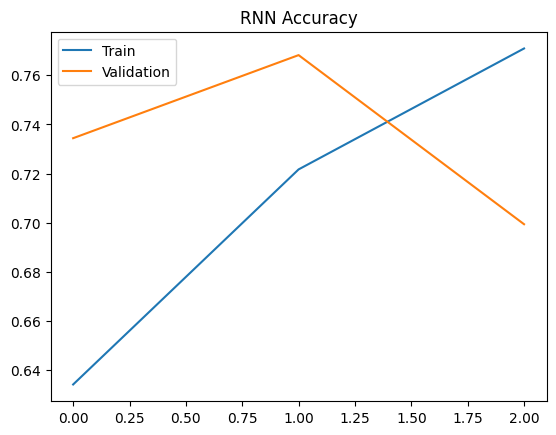

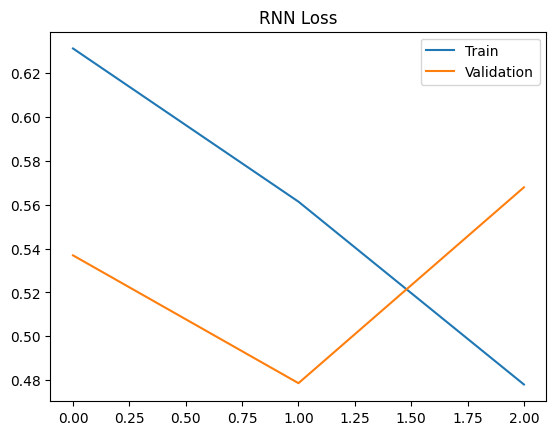

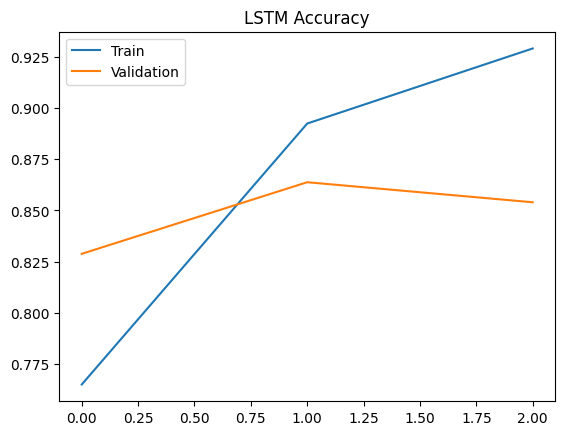

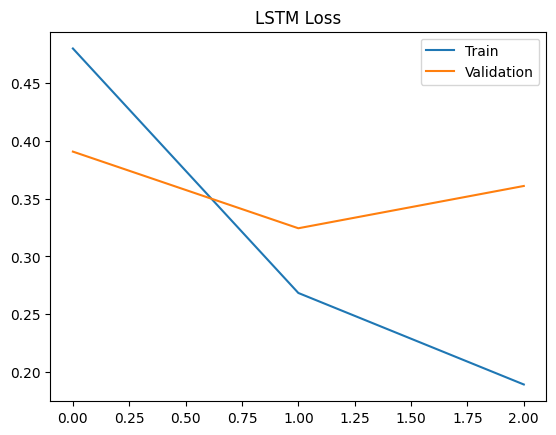

In [9]:
# Graph Plot

# RNN Accuracy
plt.plot(rnn_history.history['accuracy'])
plt.plot(rnn_history.history['val_accuracy'])
plt.title("RNN Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# RNN Loss
plt.plot(rnn_history.history['loss'])
plt.plot(rnn_history.history['val_loss'])
plt.title("RNN Loss")
plt.legend(["Train", "Validation"])
plt.show()

# LSTM Accuracy
plt.plot(lstm_history.history['accuracy'])
plt.plot(lstm_history.history['val_accuracy'])
plt.title("LSTM Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# LSTM Loss
plt.plot(lstm_history.history['loss'])
plt.plot(lstm_history.history['val_loss'])
plt.title("LSTM Loss")
plt.legend(["Train", "Validation"])
plt.show()